In [45]:
# etapa 2 - concatenar os dados de criminalidade
import pandas as pd 

# para guardar os dataframes
lista_dfs_crimes = []

anos = [2021, 2022, 2023, 2024, 2025, 2026]
for ano in anos:
    caminho = f'Data/dado_criminal/SPJ_{ano}.csv'
    df_temp = pd.read_csv(caminho, sep=';', encoding='latin-1', low_memory=False)
    lista_dfs_crimes.append(df_temp)

df_crimes_rs = pd.concat(lista_dfs_crimes, ignore_index=True)


# drop das colunas vazias, toda coluna q tiver como unnamed no nome
colunas_vazias = [col for col in df_crimes_rs.columns if 'Unnamed' in str(col)]
df_crimes_rs.drop(columns=colunas_vazias, inplace=True)


# renomeado as colunas para facilitar 
df_crimes_rs.rename(columns={
    "Sequência": "id",
    "Data Fato": "data",
    "Hora Fato": "hora",
    "Grupo Fato": "grupo_crime",
    "Tipo Enquadramento": "crime",
    "Tipo Fato": "status",
    "Municipio Fato": "municipio",
    "Local Fato": "local",
    "Bairro": "bairro",
    "Quantidade Vítimas": "qtd_vitimas",
    "Idade Vítima": "idade_vitima",
    "Sexo Vítima": "sexo_vitima",
    "Cor Vítima": "cor_vitima"
}, inplace=True)

# drop da coluna ... que sobrou e ta no csv
if '...' in df_crimes_rs.columns:
    df_crimes_rs.drop(columns=['...'], inplace=True)

# visualização
print("Tamanho do DataSet", df_crimes_rs.shape)
df_crimes_rs.info()

# filtro e padronização de municipio
df_crimes_rs["municipio"] = df_crimes_rs["municipio"].str.strip().str.lower()

df_crimes_pf = df_crimes_rs[df_crimes_rs["municipio"] == "passo fundo"]

print(df_crimes_pf["municipio"].unique())
print(df_crimes_pf.shape)
print("\nNumero de Nulos:")
df_crimes_pf.isna().sum()


Tamanho do DataSet (3218268, 13)
<class 'pandas.DataFrame'>
RangeIndex: 3218268 entries, 0 to 3218267
Data columns (total 13 columns):
 #   Column        Dtype  
---  ------        -----  
 0   id            object 
 1   data          str    
 2   hora          str    
 3   grupo_crime   str    
 4   crime         str    
 5   status        str    
 6   municipio     str    
 7   local         str    
 8   bairro        str    
 9   qtd_vitimas   float64
 10  idade_vitima  float64
 11  sexo_vitima   str    
 12  cor_vitima    str    
dtypes: float64(2), object(1), str(10)
memory usage: 319.2+ MB
<StringArray>
['passo fundo']
Length: 1, dtype: str
(67274, 13)

Numero de Nulos:


id                 0
data               0
hora               0
grupo_crime        0
crime              0
status             0
municipio          0
local              0
bairro          7498
qtd_vitimas        0
idade_vitima    9029
sexo_vitima     9104
cor_vitima      9024
dtype: int64

In [ ]:
# etapa 3 - limpeza e padronização

# idade_vitima preenche com média
df_crimes_pf["idade_vitima"] = df_crimes_pf["idade_vitima"].fillna(df_crimes_pf["idade_vitima"].mean())

#sexo_vitima preenche com ignorado
df_crimes_pf["sexo_vitima"] = df_crimes_pf["sexo_vitima"].fillna("ignorado")

# cor_vitima preenche com ignorado
df_crimes_pf["cor_vitima"] = df_crimes_pf["cor_vitima"].fillna("ignorado")

# bairro preenche como desconhecido
df_crimes_pf["bairro"] = df_crimes_pf["bairro"].fillna("desconhecido")


#remover duplicatas
df_crimes_pf.drop_duplicates(inplace=True)


#padronização de texto
colunas_texto = ["grupo_crime", "crime", "status", "bairro"]

for col in colunas_texto:
    df_crimes_pf[col] = df_crimes_pf[col].str.lower().str.strip()

# padronização da data
df_crimes_pf["data"] = pd.to_datetime(df_crimes_pf["data"], format="%d/%m/%Y")


# verificação
print("valores nulos pós tratamento: ")
print(df_crimes_pf.isna().sum())

print("\nShape final:")
print(df_crimes_pf.shape)


valores nulos pós tratamento: 
id              0
data            0
hora            0
grupo_crime     0
crime           0
status          0
municipio       0
local           0
bairro          0
qtd_vitimas     0
idade_vitima    0
sexo_vitima     0
cor_vitima      0
dtype: int64

Shape final:
(67274, 13)


In [ ]:
# etapa 4 - integração de dados metereológicos

# agrupar por data
df_crimes_pf["data"] = pd.to_datetime(df_crimes_pf["data"], errors="coerce")
df_crimes_diario = df_crimes_pf.groupby("data").size().reset_index(name="qtd_crimes")

# armazenar os dados de clima
lista_clima = []

for ano in anos:
    caminho = f'Data/dado_clima/INMET_{ano}.CSV'
    
    df_temp = pd.read_csv(caminho, sep=';', encoding='latin-1', skiprows=8) # =8 para pular cabeçalho inicial
    lista_clima.append(df_temp)

df_clima = pd.concat(lista_clima, ignore_index=True)

# nomes simplificados para as principais colunas
df_clima.rename(columns={
    "Data": "data",
    "PRECIPITAÇÃO TOTAL, HORÁRIO (mm)": "precipitacao",
    "TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)": "temperatura"
}, inplace=True)


# converte a data
df_clima["data"] = pd.to_datetime(df_clima["data"], format="%Y/%m/%d")

#converter para numero pq ta string
df_clima["temperatura"] = df_clima["temperatura"].str.replace(",", ".")
df_clima["temperatura"] = pd.to_numeric(df_clima["temperatura"], errors="coerce")

df_clima["precipitacao"] = df_clima["precipitacao"].str.replace(",", ".")
df_clima["precipitacao"] = pd.to_numeric(df_clima["precipitacao"], errors="coerce")

# agrupa por dia
df_clima_diario = df_clima.groupby("data").agg({
    "precipitacao": "sum",
    "temperatura": "mean"
}).reset_index()


# merge dos dados
# utilizado merge do tipo inner, mantendo apenas datas presentes em ambos os datasets para garantir consistência na análise
df_final = pd.merge(df_crimes_diario, df_clima_diario, on="data", how="inner")
#os nulos de temp foram preenchidos com a media, pq tem falhas nos dados de temperatura, mas nao compromete a analise
df_final["temperatura"] = df_final["temperatura"].fillna(df_final["temperatura"].mean())

#validacao
print("Shape do dataset final:")
print(df_final.shape)

print("\nValores nulos:")
print(df_final.isna().sum())



Shape do dataset final:
(618, 4)

Valores nulos:
data            0
qtd_crimes      0
precipitacao    0
temperatura     0
dtype: int64


In [ ]:
# etapa 5 - transformações

# drop nos nulos
df_final = df_final.dropna()

# achar outliers pelo método IQR, foi identificado e removido os valores fora do padrao esperado
Q1 = df_final["qtd_crimes"].quantile(0.25)
Q3 = df_final["qtd_crimes"].quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

df_sem_outliers = df_final[
    (df_final["qtd_crimes"] >= lim_inf) & (df_final["qtd_crimes"] <= lim_sup)
]


# normalização
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

# aplicada normalização Min-Max na variável de quantidade de crimes, para melhor comparação e análise dos dados
df_sem_outliers["qtd_crimes_norm"] = scaler.fit_transform(df_sem_outliers[["qtd_crimes"]])


#validacao
print("Shape antes:", df_final.shape)
print("Shape depois:", df_sem_outliers.shape)

print("\nResumo:")
print(df_sem_outliers.describe())



Shape antes: (618, 4)
Shape depois: (617, 5)

Resumo:
                             data  qtd_crimes  precipitacao  temperatura  \
count                         617  617.000000    617.000000   617.000000   
mean   2023-11-05 09:38:48.038898   42.453809      5.872285    18.317972   
min           2021-01-10 00:00:00   19.000000      0.000000     3.616667   
25%           2022-10-11 00:00:00   36.000000      0.000000    15.441667   
50%           2023-11-09 00:00:00   43.000000      0.000000    18.620833   
75%           2024-12-07 00:00:00   49.000000      2.600000    21.833333   
max           2026-03-02 00:00:00   66.000000    155.000000    27.508333   
std                           NaN    9.061204     15.946686     4.705062   

       qtd_crimes_norm  
count       617.000000  
mean          0.499017  
min           0.000000  
25%           0.361702  
50%           0.510638  
75%           0.638298  
max           1.000000  
std           0.192792  


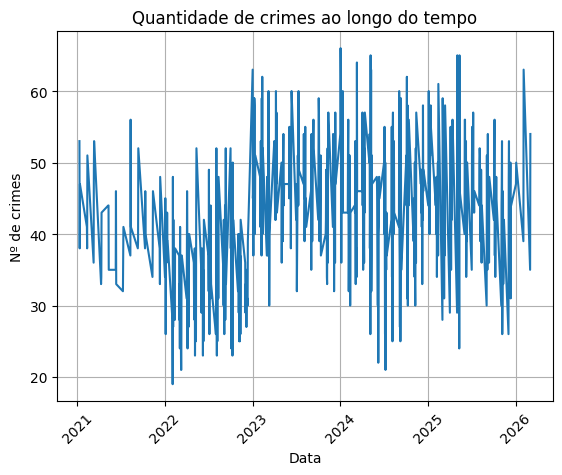

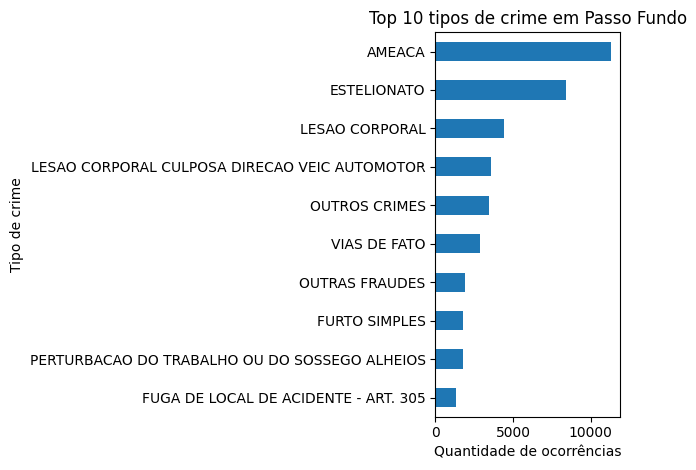

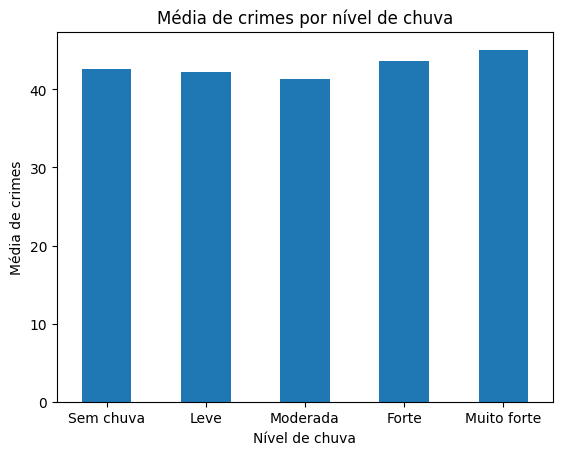

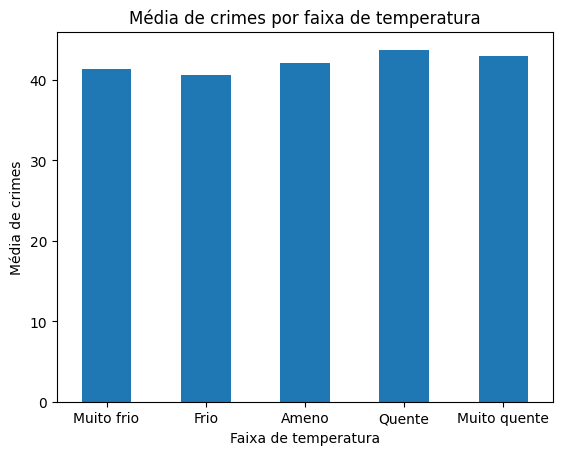

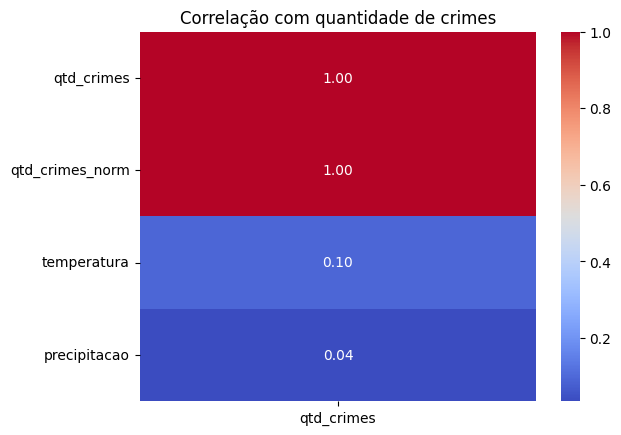

In [ ]:
# etapa 6

import matplotlib.pyplot as plt
import seaborn as sns

# garantir ordenação por data
df_sem_outliers = df_sem_outliers.sort_values("data")

# crimes ao longo do tempo
plt.figure()
plt.plot(df_sem_outliers["data"], df_sem_outliers["qtd_crimes"])
plt.title("Quantidade de crimes ao longo do tempo")
plt.xlabel("Data")
plt.ylabel("Nº de crimes")

plt.xticks(rotation=45)
plt.grid()
plt.show()

# contar quantidade por tipo de crime
top_crimes = df_crimes_pf["crime"].value_counts().head(10)
top_crimes.index = top_crimes.index.str.slice(0, 80)

plt.figure()
top_crimes.sort_values().plot(kind="barh")

plt.title("Top 10 tipos de crime em Passo Fundo")
plt.xlabel("Quantidade de ocorrências")
plt.ylabel("Tipo de crime")
plt.tight_layout()
plt.show()

# chuva x crimes
bins_chuva = [-1, 0, 10, 30, 60, 200]
labels_chuva = ["Sem chuva", "Leve", "Moderada", "Forte", "Muito forte"]

df_sem_outliers["faixa_chuva"] = pd.cut(
    df_sem_outliers["precipitacao"],
    bins=bins_chuva,
    labels=labels_chuva
)

media_chuva = df_sem_outliers.groupby("faixa_chuva")["qtd_crimes"].mean()
plt.figure()
media_chuva.plot(kind="bar")

plt.title("Média de crimes por nível de chuva")
plt.xlabel("Nível de chuva")
plt.ylabel("Média de crimes")
plt.xticks(rotation=0)
plt.show()

# temperatura x crime
bins_temp = [0, 10, 15, 20, 25, 35]
labels_temp = ["Muito frio", "Frio", "Ameno", "Quente", "Muito quente"]

df_sem_outliers["faixa_temp"] = pd.cut(
    df_sem_outliers["temperatura"],
    bins=bins_temp,
    labels=labels_temp
)

media_temp = df_sem_outliers.groupby("faixa_temp")["qtd_crimes"].mean()
plt.figure()
media_temp.plot(kind="bar")

plt.title("Média de crimes por faixa de temperatura")
plt.xlabel("Faixa de temperatura")
plt.ylabel("Média de crimes")
plt.xticks(rotation=0)
plt.show()


# correlação
corr = df_sem_outliers.corr(numeric_only=True)
corr_crimes = corr[["qtd_crimes"]].sort_values(by="qtd_crimes", ascending=False)
plt.figure()

sns.heatmap(
    corr_crimes,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlação com quantidade de crimes")
plt.show()